# Introduction

In part 1 of this assessment, you will complete several requested SQL queries in order to extract data, analyze, and provide insights from a single provided SQL database. You will also visualize the key results of 3 of these queries. There are also several 'Reflection' questions that ask you to write out a text based answer in the provided markdown cell. Following the guided question and answer section, in part 2 you will explore a second dataset on your own using SQL in order to conduct a preliminary analysis. You will be asked to produce a very short slide presentation highlighting the work you did for this second section.

## Objectives
You will be able to:
- Interpret "word problems" and translate them into SQL queries
- Decide and perform whichever type of JOIN is best for retrieving desired data
- Use GROUP BY statements to apply aggregate functions like COUNT, MAX, MIN, and SUM
- Use the HAVING clause to compare different aggregates
- Write subqueries to decompose complex queries
- Visualize data using matplotlib, seaborn, or pandas
- Choose the correct chart type based on the given data


## Part 1: Guided SQL Queries

### Your Task: Querying a Customer Database

![toy car picture](images/toycars.jpg)


### Business Understanding
Your employer sells wholesale miniature models of products such as classic cars, motorcycles, and planes. They want you to pull several reports on different segments of their past customers, in order to better understand past sales as well as determine which customers will receive promotional material. They are also interested in investigating which products have performed the best, as well as having several smaller asks.

In addition to providing the requested data from the SQL database you have also been asked to create some basic visuals to display some of the more insightful information. It is up to your discretion to choose the correct plot/chart type for the data in question. **Questions that want you to visualize the results will be explicitly marked**.

### Data Understanding
You may remember this database from a previous lab. As a refresher, here's the ERD diagram for this database:

![ERD picture](images/ERD.png)

The queries you are asked to write will become more complex over the course of the lab.



### Getting Started
For this assessment you are expected to make use of both sqlite3 and the Pandas libraries in order to write, execute, and return SQL queries as a Pandas DataFrame. Assign each returned answer as its own explicit variable.

For the visualization piece you are expected to utilize either Pandas, Seaborn, or Matplotlib to create your visuals. Make sure you are providing verbose labels and titles according to the data you are being asked to visualize. Do not worry too much about choosing a 'style' or 'context' instead focus on conveying the requested information correctly.

### Step 1: Connect to Data

In the cell below
- Import the necessary libraries
- Establish a connection to the database data.sqlite

In [88]:
# Replace None with your code
# Imports
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create connection to database
conn = sqlite3.connect("data.sqlite")

### Step 2: Limited Edition California Product
The California sales rep team is interested in running promotional material for a new limited edition model they are releasing based on the famous San Francisco Cable Cars. This product will only be available to customer stores based in California and given its high price value they want to first target promotional material to existing California customers with a high credit limit. Upon communicating with the accounting department, a credit limit of over 25,000 is considered to be high. 

Execute a SQl query that returns which customers the sales rep team wants to market to first.

In [89]:
# Replace None with your code
california_high_credit_customers = pd.read_sql("""
                                               SELECT customerName, state, creditLimit
                                               FROM customers
                                               WHERE state='CA' AND creditLimit > 25000;"""
                                               , conn)
# california_high_credit_customers

### Step 3: International Collectable Campaign

The international sales rep team has reached out to you to help them identify partners for a 'Collectable' marketing campaign that highlights the potential collectors value in purchasing these model kits. They want to try and promote a 'collect them all' mentality. The team had a great idea to partner with any of their international customers (non-US) who have "Collect" in their name as a tie in to the larger theme.

Execute a SQL that returns the customers in question.

In [90]:
# Replace None with your code
collectors = pd.read_sql("""
                         SELECT * 
                         FROM customers 
                         WHERE country != 'USA' 
                            AND customerName LIKE '%Collect%';""", conn)
# collectors

## Reflection Question:

Describe the WHERE clause you used in the above query to a non-technical manager who wants to be ensured that you are properly filtering and only selecting the requested data. How is the operator and conditional expression you are using acting to accomplish this?

## Type your answer in markdown here!
The `WHERE` clause in the above query uses two conditions joined by the `AND` operator, meaning both must be true for a row to be included.

1. `country != 'USA'` -> This filters out any customer whose country is the United States, keeping only international customers.
2. `customerName LIKE '%Collect%'` -> The `LIKE` operator with the `%`  acts like a search. The `%` means "anything can appear here," so `'%Collect%'` matches any customer name that contains the word *Collect* anywhere be it at the beginning, middle, or end.

Together, these two conditions ensure we are only looking at international customers whose store name includes the word "Collect" 

### Step 4: USA Credit and Inventory Policy - Visual Required
The USA based product team is planning to adjust its credit policies and inventory allocation strategy based on the average credit limit of its customers. They would like to target this strategy at a state level with several goals in mind. 
1. Optimize inventory distribution:
    - States with higher average credit limits might be able to place larger orders, justifying priority in inventory allocation.
    - This could help ensure that states with more purchasing power always have products in stock.
2. Tailor credit policies:
    - Adjust credit limits for new customers based on the state average.
    - Identify states where they might be too conservative or too liberal with credit limits.
3. Target marketing and sales efforts:
    - Focus promotional campaigns on states with higher credit limits, potentially leading to larger orders.
    - Develop strategies to increase sales in states with lower average credit limits.

Execute a SQl query that returns the information required to address this ask.

In [91]:
# Replace None with your code
avg_credit_per_state = pd.read_sql("""
                                   SELECT state, ROUND(AVG(creditLimit), 2) as avg_credit
                                   FROM customers
                                   GROUP BY state
                                   HAVING country = 'USA';
                                   """, conn)
avg_credit_per_state

,state,avg_credit
0,CA,83854.55
1,CT,57350.00
2,MA,70755.56
3,NH,114200.00
4,NJ,43000.00
5,NV,71800.00
6,NY,89966.67
7,PA,84766.67


Once you have the information returned in a dataframe, select an appropriate visualization to represent this data. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

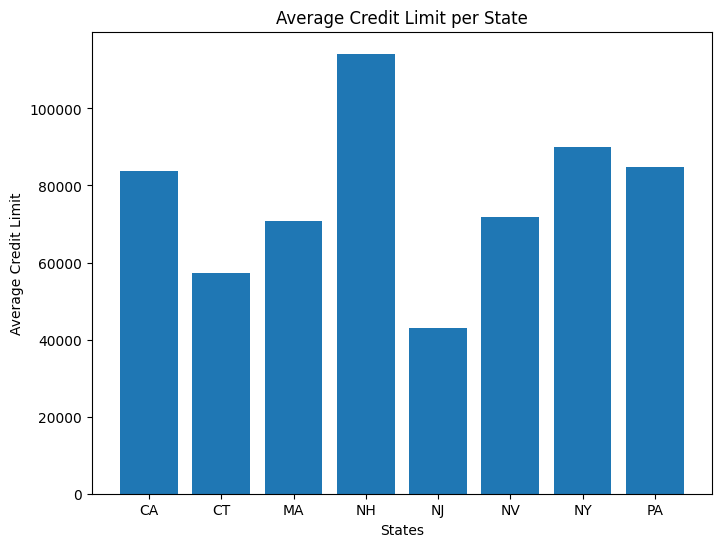

In [92]:
# Replace None with your visual code
# Produce a visual to represent the average credit limit by state
plt.figure(figsize=(8,6))
plt.bar(data=avg_credit_per_state, x='state', height='avg_credit')
plt.title("Average Credit Limit per State")
plt.xlabel("States")
plt.ylabel("Average Credit Limit")
plt.show()

### Step 5: Top Customers - Visual Required
The company is approaching its 10 year anniversary and wants to acknowledge and thank its top customers with personalized communication. They have asked you to determine the top 10 customers based on the total amount of payments made, making sure to return the customer name for clarity. 

Execute a SQl query that returns the information required to address this ask.


In [93]:
# Replace None with your code
top_10_customers = pd.read_sql("""
                               SELECT c.customerName, SUM(p.amount) AS amount_spent
                               FROM customers c
                               LEFT JOIN payments p
                                ON c.customerNumber = p.customerNumber
                               GROUP BY c.customerNumber
                               ORDER BY amount_spent DESC
                               LIMIT 10""", conn)

Once you have the information returned in a dataframe, select an appropriate visualization to represent this data. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

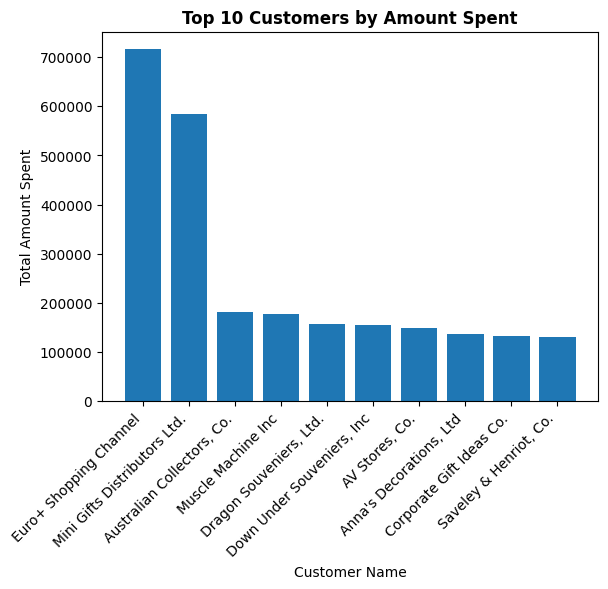

In [94]:
# Replace None with your visual code
# Produce a visual to represent the top ten customers in terms of total payments
plt.bar(data=top_10_customers, height='amount_spent', x='customerName')
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Customers by Amount Spent", fontweight='bold')
plt.ylabel("Total Amount Spent")
plt.xlabel("Customer Name")
plt.show()

### Step 6: Top Customer + Product Quantities
The product team is running an analysis on popular and common products sold to each customer in order to try and determine what new products they should be looking at to include in their catalog. This data will also be used by individual sales reps to recommend similar products to each customer next time they place an order. 

They have asked you to query information, for each customer, about any product they have purchased 10 or more units of. In addition they would like the full set of data to be sorted in ascending order by the total amount purchased.

Execute a SQl query that returns the information required to address this ask.

Hint: For this one, you'll need to make use of HAVING, GROUP BY, and ORDER BY — make sure you get the order of them correct!

In [95]:
# Replace None with you code
popular_products = pd.read_sql("""
                                SELECT c.customerNumber, c.customerName,
                                p.productName, SUM(od.quantityOrdered) AS total_orders,
                                SUM(od.quantityOrdered * od.priceEach) AS total_amount
                                FROM customers c
                                JOIN orders o 
                                    ON c.customerNumber = o.customerNumber
                                JOIN orderDetails od
                                    ON od.orderNumber = o.orderNumber
                                JOIN products p
                                    ON p.productCode = od.productCode
                                GROUP BY c.customerNumber, p.productCode
                                HAVING total_orders >= 10
                                ORDER BY total_amount;""", conn)
# popular_products

### Step 7: Product Analysis - Visual Required

The product team is looking into the demand across its different product lines. They are conducting a comprehensive review of its product portfolio and inventory management strategies. You have been asked to query data pertaining to each different product line, that contains the total quantity ordered and the total number of products for each respective product line. By examining the number of products and total quantity ordered for each product line, the company aims to:
1. Optimize product mix:
    - Identify which product lines have the most diverse offerings (high number of products)
    - Determine which lines are most popular (high total quantity ordered)
    - Compare if lines with more products necessarily lead to more orders
2. Improve inventory management:
    - Adjust stock levels based on the popularity of each product line
    - Identify potential overstocking in lines with low order quantities
    - Ensure adequate variety in high-performing product lines
3. Adjust marketing strategy:
    - Focus promotional efforts on product lines with high potential (many products but lower order quantities)
    - Capitalize on the popularity of high-performing lines in marketing campaigns
4. Advise Product development:
    - Invest in expanding product ranges for lines with high order quantities
    - Consider phasing out or revamping product lines with low numbers of products and low order quantities

Hint: Think about how you can and might have to utilize SQL DISTINCT statement

Execute a SQl query that returns the information required to address this ask.

In [96]:
# Replace None with your code
product_line_demand = pd.read_sql("""
                                  SELECT p.productLine, SUM(od.quantityOrdered) AS total_quantity,
                                    COUNT(DISTINCT p.productCode) AS total_products
                                  FROM products p
                                  JOIN orderDetails od
                                    ON od.productCode = p.productCode
                                  GROUP BY p.productLine;""", conn)
product_line_demand

,productLine,total_quantity,total_products
0,Classic Cars,35582,37
1,Motorcycles,12778,13
2,Planes,11872,12
3,Ships,8532,9
4,Trains,2818,3
5,Trucks and Buses,11001,11
6,Vintage Cars,22933,24


Once you have the information returned in a dataframe, select an appropriate visualization to represent the relationship between total quantity ordered and the number of products in order to perform a preliminary investigation into the question of if more products lead to more orders. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

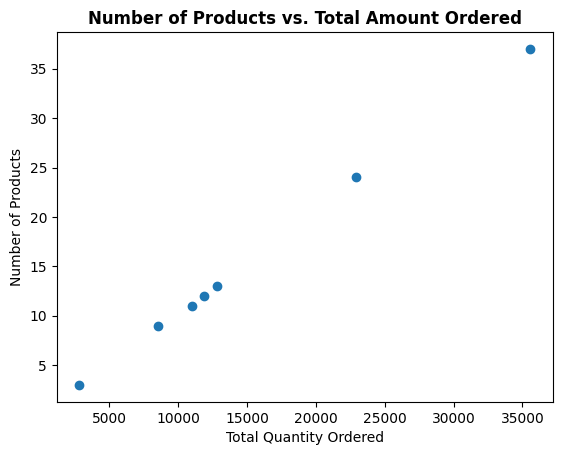

In [97]:
# Replace None with your visual code
# Produce a visual to represent the the relation between number of products and the total amount ordered
plt.scatter(data=product_line_demand, y='total_products', x='total_quantity')
plt.title("Number of Products vs. Total Amount Ordered", fontweight='bold')
plt.ylabel("Number of Products")
plt.xlabel("Total Quantity Ordered")
plt.show()

## Reflection Question:

Please explain your choice in the type of visual you used in order to highlight and represent the data from the above query. In a non-technical manner explain why that chart type makes sense for the information being conveyed. What does this visual convey in the context of the question it was asked for?

## Type your answer in markdown here!
A scatter plot was the best choice here because it allows each product line to be shown as its own point, making it easy to see the relationship between the number of products offered and the total quantity ordered. Instead of just comparing totals, this chart reveals how these two factors move together, helping answer the key question of whether having more products leads to higher demand. By looking at the overall pattern of the points, we can quickly notice a general upward trend, suggesting that product lines with a wider variety tend to generate more orders. At the same time, the chart makes it easy to spot exceptions, such as product lines that have many products but relatively low demand, or those with fewer products but strong sales. In the context of the business problem, this visual helps decision-makers understand how product diversity impacts performance, guiding choices around inventory, marketing focus, and future product development.


### Step 8: Remote Offices
Upper management is considering a shift to hybrid and remote work for certain locations and roles. They have tasked you with providing them data about employees who work in any office that has fewer than 5 total employees so they can better understand how to support those employees remotely when offices are shut down. 

Be sure to include information about the employees job and supervisor so management can adjust everyone to remote work properly.

Hint: Utilize a subquery to find the relevant offices

Execute a SQl query that returns the information required to address this ask.

In [98]:
pd.read_sql("PRAGMA table_info(employees)", conn)
# pd.read_sql("SELECT jobTitle from employees", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,employeeNumber,,0,None,0
1,1,lastName,,0,None,0
2,2,firstName,,0,None,0
3,3,extension,,0,None,0
4,4,email,,0,None,0
5,5,officeCode,,0,None,0
6,6,reportsTo,,0,None,0
7,7,jobTitle,,0,None,0


In [99]:
# Replace None with your code
few_office_employees = pd.read_sql("""
                                   SELECT e.firstName|| ' ' ||e.lastName AS name, e.jobTitle,
                                        m.firstName|| ' ' ||m.lastName AS supervisor,
                                        e.officeCode
                                   FROM employees e
                                   LEFT JOIN employees m
                                        ON e.reportsTo = m.employeeNumber
                                   WHERE e.officeCode IN(
                                        SELECT officeCode
                                        FROM employees
                                        GROUP BY officeCode
                                        HAVING COUNT(*) < 5);""", conn)
few_office_employees

,name,jobTitle,supervisor,officeCode
0,William Patterson,Sales Manager (APAC),Mary Patterson,6
1,Julie Firrelli,Sales Rep,Anthony Bow,2
2,Steve Patterson,Sales Rep,Anthony Bow,2
3,Foon Yue Tseng,Sales Rep,Anthony Bow,3
4,George Vanauf,Sales Rep,Anthony Bow,3
5,Larry Bott,Sales Rep,Gerard Bondur,7
6,Barry Jones,Sales Rep,Gerard Bondur,7
7,Andy Fixter,Sales Rep,William Patterson,6
8,Peter Marsh,Sales Rep,William Patterson,6
9,Tom King,Sales Rep,William Patterson,6


## Reflection Question:

Describe how you decided on the subquery that you used in the query above? This answer can be technically in nature, describing your thought process in how the main query is utilizing the subquery to return the correct data.

## Type your answer in markdown here!

### Step 9: Close the Connection

Now that you are finished executing your queries and retrieving the required information you always want to make sure to close the connection to your database.

In [100]:
# Replace None with your code
conn.close()

### End of Guided Section
In this initial portion of the assessment, you produced several data queries and visualizations for a model company, mainly focused around its customer and product data. You wrote and engineered specific SQL queries to address pertinent questions and asks from the company. Along the way, you utilized many of the major concepts and keywords associated with SQL SELECT queries: FROM, WHERE, GROUP BY, HAVING, ORDER BY, JOIN, SUM, COUNT, and AVG.

## Part 2: Exploratory Analysis with SQL
In this open-ended exploratory section, you will analyze real-world data from the movie industry. As a data analyst, you have the freedom to investigate questions and topics that intrigue you within this dataset. The database schema and Entity-Relationship Diagram (ERD) are provided below for your reference. A general overview and instructions are also provided below.

In [101]:
# Run this cell without changes
import zipfile

zip_file_path = 'im.db.zip'
extract_to_path = './'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to_path)

# Connection
conn4 = sqlite3.connect('im.db')

# Schema
schema_df = pd.read_sql("""
SElECT * FROM sqlite_master                        
""", conn4)
schema_df

,type,name,tbl_name,rootpage,sql
0,table,movie_basics,movie_basics,2,"CREATE TABLE ""movie_basics"" (\n""movie_id"" TEXT..."
1,table,directors,directors,3,"CREATE TABLE ""directors"" (\n""movie_id"" TEXT,\n..."
2,table,known_for,known_for,4,"CREATE TABLE ""known_for"" (\n""person_id"" TEXT,\..."
3,table,movie_akas,movie_akas,5,"CREATE TABLE ""movie_akas"" (\n""movie_id"" TEXT,\..."
4,table,movie_ratings,movie_ratings,6,"CREATE TABLE ""movie_ratings"" (\n""movie_id"" TEX..."
5,table,persons,persons,7,"CREATE TABLE ""persons"" (\n""person_id"" TEXT,\n ..."
6,table,principals,principals,8,"CREATE TABLE ""principals"" (\n""movie_id"" TEXT,\..."
7,table,writers,writers,9,"CREATE TABLE ""writers"" (\n""movie_id"" TEXT,\n ..."


## The Data

![movie ERD](images/movie_data_erd.jpeg)
### Database Content:

- Source: IMDB
- Time Range: Movies released between 2010 and 2019
- Note: Exclude any movies with a start_year after 2019 as this data is not current or accurate

Available Data Categories:
- Genre
- Runtime
- Personnel (writers, directors, actors)
- Movie ratings

### Objectives:

Initial Exploration:
- Use SQL in combination with Pandas to explore the database
- Identify interesting trends, patterns, or relationships in the data

Business Question Formulation:
- Develop at least one substantial business question for deeper analysis
- Ensure the question is relevant, specific, and can be addressed with the available data

Data Cleaning Assessment:
- Identify potential data cleaning tasks necessary for your deeper analysis
- Note: You are not required to perform the cleaning, only to recognize and list the necessary tasks

Null Value Handling:
- Be aware that the dataset contains null values in certain fields
- Exclude these null values from your exploration
- Do not attempt to input or fill in missing information

### Deliverables:

You need to produce a short slide presentation (3-5 slides) that highlights the three key deliverables below. Utilize a data visualization to support the second deliverable.

1. A summary of your initial data exploration findings
    - Can be bulleted or sentence form
2. At least one well-formulated business question for further analysis
    - Should stem from a relevant trend or pattern your initial exploration identified
3. A list of potential data cleaning tasks identified during your exploration
    - This can and should include things like data normalization/standardization and null handling

Tips for Success:

Begin with broad exploratory queries to understand the data's scope and content. Then focus on honing in on interesting relationships between different data categories. Consider industry trends, audience preferences, or financial aspects when formulating your business question. Pay attention to data quality issues, inconsistencies, or limitations that might affect your analysis. Remember, the goal is to demonstrate your analytical thinking and ability to derive meaningful insights from complex datasets. Good luck with your exploration!

NOTE: You do not need to explore every aspect of this database. Find something that you think is interesting or relevant about the data and focus your exploration there.

In [102]:
# Begin your code here
# importing necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn4)
tables

,name
0,movie_basics
1,directors
2,known_for
3,movie_akas
4,movie_ratings
5,persons
6,principals
7,writers


In [103]:
# Remove all movies after 2019
print(f"Shape before removing movies after 2019: {pd.read_sql('SELECT * FROM (movie_basics);', conn4).shape}")
movie_basics = pd.read_sql("""SELECT * FROM movie_basics
                           WHERE start_year < 2020;""", conn4)
print(f"\nShape after removing movies after 2019: {movie_basics.shape}")

# Dropping null values
movie_basics.dropna(inplace=True)

Shape before removing movies after 2019: (146144, 6)

Shape after removing movies after 2019: (145081, 6)


In [104]:
# get the ratings from movie_ratings table
ratings_df = pd.read_sql("SELECT * FROM movie_ratings;", conn4)

# merge movie_basics with ratings_df
movies_df = movie_basics.merge(ratings_df, on='movie_id', how='inner')
movies_df.shape

(65720, 8)

In [105]:
# Split genres since some movies have multiple genres
movies_df.genres = movies_df.genres.str.split(',')
# explode genres into seperate rows 
movies_df = movies_df.explode('genres')

In [106]:
movies_df.head()

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,averagerating,numvotes
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,Action,7.0,77
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,Crime,7.0,77
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,Drama,7.0,77
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,Biography,7.2,43
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,Drama,7.2,43


In [125]:
# group by genre and calculate metrics
genre_summary = movies_df.groupby('genres').agg(
    avg_rating=('averagerating', 'mean'),
    total_votes=('numvotes', 'sum'),
    movie_count=('movie_id', 'count')
).sort_values(by='avg_rating', ascending=False).reset_index()
genre_summary = genre_summary[genre_summary['movie_count'] > 10]
# genre_summary

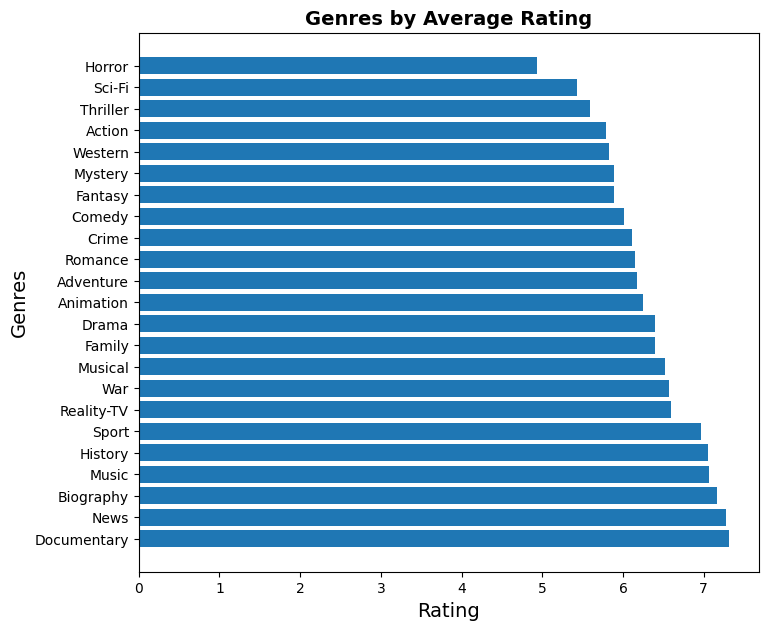

In [108]:
# visualize above data
plt.figure(figsize=(8,7))
plt.barh(data=genre_summary, y='genres', width='avg_rating')
plt.title("Genres by Average Rating", fontweight='bold', fontsize=14)
plt.ylabel('Genres', fontsize=14)
plt.xlabel("Rating", fontsize=14);

The dataset was filtered to include only movies between 2010 and 2019. Records with missing genre or rating information were excluded to ensure data quality. Since movies can belong to multiple genres, the genre column was split and expanded to allow accurate aggregation. The cleaned data was then grouped by genre to calculate average ratings, total votes, and movie counts for analysis.

### Business question
What combination of genre, runtime, and key personnel is most predictive of a movie achieving both high audience ratings and high engagement between 2010 and 2019?

In [109]:
# convert runtime_minutes to numeric
movies_df['runtime_minutes'] = pd.to_numeric(movies_df['runtime_minutes'], errors='coerce')

# Create bins
movies_df['runtime_band'] = pd.cut(
    movies_df['runtime_minutes'],
    bins=[0, 90, 120, 300],
    labels=['Short (<90)', 'Standard (90–120)', 'Long (120+)']
)

In [110]:
movies_df['success_score'] = movies_df['averagerating'] * np.log1p(movies_df['numvotes'])
movies_df

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,averagerating,numvotes,runtime_band,success_score
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,Action,7.0,77,Long (120+),30.496962
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,Crime,7.0,77,Long (120+),30.496962
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,Drama,7.0,77,Long (120+),30.496962
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,Biography,7.2,43,Standard (90–120),27.246165
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,Drama,7.2,43,Standard (90–120),27.246165
...,...,...,...,...,...,...,...,...,...,...
65716,tt9913056,Swarm Season,Swarm Season,2019,86.0,Documentary,6.2,5,Short (<90),11.108909
65717,tt9913084,Diabolik sono io,Diabolik sono io,2019,75.0,Documentary,6.2,6,Short (<90),12.064643
65718,tt9914286,Sokagin Çocuklari,Sokagin Çocuklari,2019,98.0,Drama,8.7,136,Standard (90–120),42.803834
65718,tt9914286,Sokagin Çocuklari,Sokagin Çocuklari,2019,98.0,Family,8.7,136,Standard (90–120),42.803834


In [126]:
# genre and runtime analysis
genre_runtime = movies_df.groupby(['genres', 'runtime_band']).agg(
    avg_rating=('averagerating', 'mean'),
    avg_votes=('numvotes', 'mean'),
    avg_success=('success_score', 'mean'),
    movie_count=('movie_id', 'count')
).reset_index()

# Keep meaningful data only
genre_runtime = genre_runtime[genre_runtime['movie_count'] > 5]
genre_runtime.head(15)

,genres,runtime_band,avg_rating,avg_votes,avg_success,movie_count
0,Action,Short (<90),5.564467,1783.835256,24.476427,2167
1,Action,Standard (90–120),5.759339,17958.495358,35.835426,2693
2,Action,Long (120+),6.160879,34051.373780,43.098117,1434
5,Adventure,Short (<90),6.183201,1797.124434,25.804394,1768
6,Adventure,Standard (90–120),6.090831,24473.087731,38.438407,1516
7,Adventure,Long (120+),6.549552,131176.835821,56.291621,335
8,Animation,Short (<90),6.081279,2438.746002,28.933201,1063
9,Animation,Standard (90–120),6.561905,24923.013889,42.683168,504
10,Animation,Long (120+),6.739583,4049.583333,38.111948,48
11,Biography,Short (<90),7.281362,306.818091,25.048492,2012


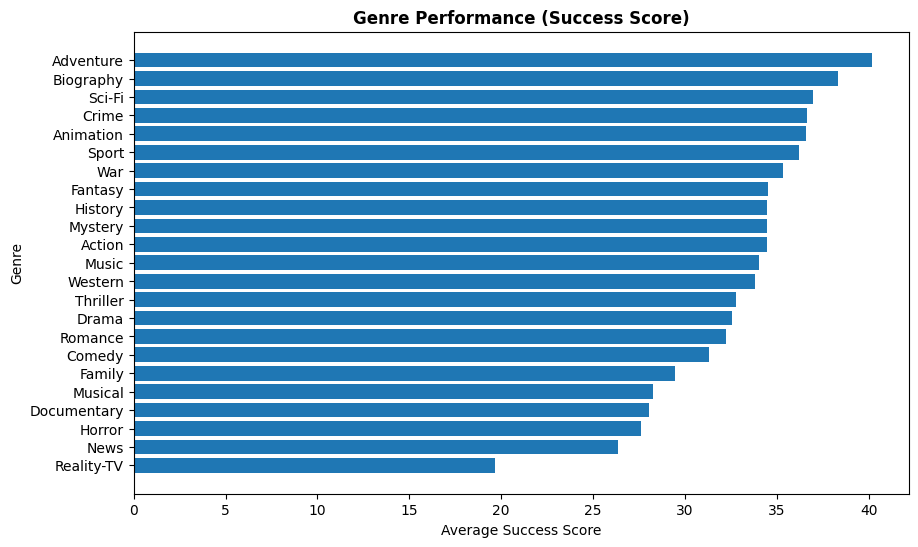

In [112]:
top_genres = genre_runtime.groupby('genres')['avg_success'].mean().sort_values()

plt.figure(figsize=(10,6))
plt.barh(top_genres.index, top_genres.values)
plt.title("Genre Performance (Success Score)", fontweight='bold')
plt.xlabel("Average Success Score")
plt.ylabel("Genre")
plt.show()

In [113]:
directors_df = pd.read_sql("SELECT * FROM directors", conn4)
people_df = pd.read_sql("SELECT * FROM persons", conn4)

In [114]:
directors_named = directors_df.merge(
    people_df,
    on='person_id',
    how='inner'
)

In [115]:
# merge with performance data 
director_perf = directors_named.merge(
    movies_df[['movie_id', 'averagerating', 'numvotes', 'success_score']],
    on='movie_id',
    how='inner'
)
director_perf.head()

,movie_id,person_id,primary_name,birth_year,death_year,primary_profession,averagerating,numvotes,success_score
0,tt0285252,nm0899854,Tony Vitale,1964.0,NaN,"producer,director,writer",3.9,219,21.035147
1,tt0462036,nm1940585,Bill Haley,NaN,NaN,"director,writer,producer",5.5,18,16.194414
2,tt0835418,nm0151540,Jay Chandrasekhar,1968.0,NaN,"director,actor,writer",5.0,8147,45.027639
3,tt0835418,nm0151540,Jay Chandrasekhar,1968.0,NaN,"director,actor,writer",5.0,8147,45.027639
4,tt0878654,nm0089502,Albert Pyun,1954.0,NaN,"director,writer,producer",5.8,875,39.297123


In [116]:
# Aggregate director performance
director_summary = director_perf.groupby('primary_name').agg(
    avg_rating=('averagerating', 'mean'),
    avg_votes=('numvotes', 'mean'),
    avg_success=('success_score', 'mean'),
    movie_count=('movie_id', 'count')
).reset_index()

# Filter meaniful directors 
director_summary = director_summary[director_summary['movie_count'] > 10]
# director_summary.head(10)

In [117]:
# Get top directors 
top_directors = director_summary.sort_values(
    by='avg_success',
    ascending=False
).head(10)
top_directors

,primary_name,avg_rating,avg_votes,avg_success,movie_count
9025,Christopher Nolan,8.445000,1.291055e+06,118.350934,20
3838,Anthony Russo,8.246667,6.140531e+05,109.795221,90
22870,Joe Russo,8.224176,6.073063e+05,108.899658,91
28078,Lee Unkrich,8.350000,4.797060e+05,108.383791,24
41484,Ronnie Del Carmen,8.200000,5.361810e+05,108.176277,24
667,Adrian Molina,8.400000,2.771940e+05,105.272803,12
37973,Pete Docter,8.120000,5.147345e+05,104.592168,25
11299,David Fincher,7.838462,5.295822e+05,103.033383,13
20861,Jared Bush,8.000000,3.834460e+05,102.855654,24
19840,J.J. Abrams,7.755556,5.824261e+05,102.633652,27


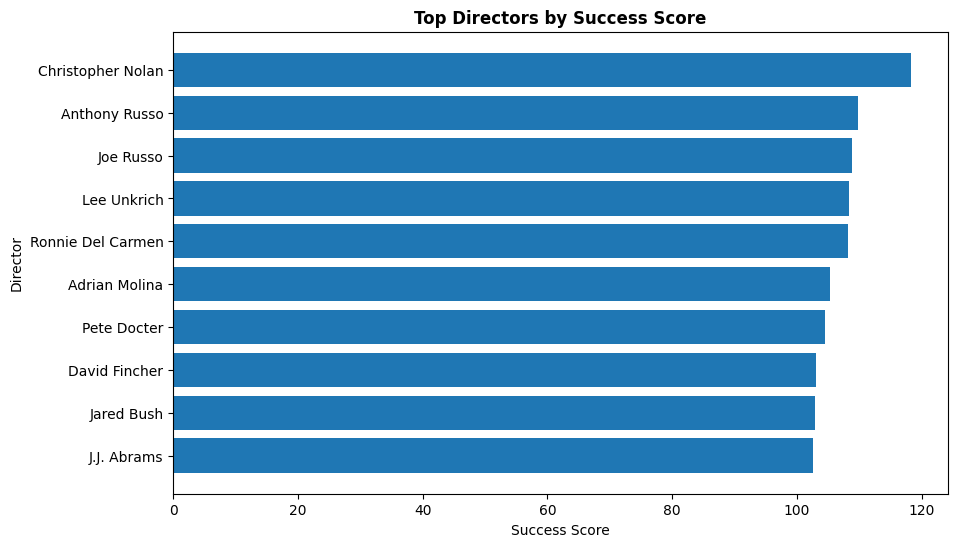

In [118]:
# visualize the above info

plt.figure(figsize=(10,6))
plt.barh(top_directors['primary_name'], top_directors['avg_success'])
plt.title("Top Directors by Success Score", fontweight='bold')
plt.xlabel("Success Score")
plt.ylabel("Director")
plt.gca().invert_yaxis()
plt.show()

The highest-performing directors between 2010–2019 are those who consistently produce high-rated, high-engagement films at scale, with Christopher Nolan and the Russo brothers representing the strongest intersection of quality and audience reach.

In [121]:
# combine director movies_df 
director_genre = directors_named.merge(
    movies_df[['movie_id', 'genres', 'averagerating', 'numvotes', 'success_score']],
    on='movie_id',
    how='inner'
)

director_genre = director_genre.dropna(subset=['primary_name', 'genres'])

In [128]:
heatmap_data = director_genre.pivot_table(
    index='primary_name',
    columns='genres',
    values='success_score',
    aggfunc='mean'
)
top_directors = director_summary.sort_values('avg_success', ascending=False).head(15)['primary_name']

heatmap_data = heatmap_data.loc[heatmap_data.index.intersection(top_directors)]
heatmap_data

genres,Action,Adult,Adventure,Animation,Biography,Comedy,Crime,Documentary,Drama,Family,...,Mystery,News,Reality-TV,Romance,Sci-Fi,Short,Sport,Thriller,War,Western
primary_name,,,,,,,,,,,,,,,,,,,,,
Adrian Molina,NaN,NaN,105.272803,105.272803,NaN,105.272803,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Anthony Russo,109.795221,NaN,109.795221,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,109.795221,NaN,NaN,NaN,NaN,NaN
Byron Howard,NaN,NaN,102.057434,102.057434,NaN,102.057434,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Chris Sanders,100.943354,NaN,100.943354,100.943354,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Christopher Nolan,117.546587,NaN,123.026059,NaN,NaN,NaN,NaN,NaN,115.083608,NaN,...,NaN,NaN,NaN,NaN,123.026059,NaN,NaN,118.802953,NaN,NaN
David Fincher,NaN,NaN,NaN,NaN,102.031896,NaN,100.367905,NaN,102.899852,NaN,...,103.478489,NaN,NaN,NaN,NaN,NaN,NaN,109.699657,NaN,NaN
Dean DeBlois,101.050365,NaN,101.050365,101.050365,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
J.J. Abrams,104.369718,NaN,104.369718,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,88.745123,NaN,NaN,NaN,97.872350,NaN,NaN,88.745123,NaN,NaN
James Mangold,101.139859,NaN,82.920361,NaN,NaN,75.868493,NaN,NaN,107.213025,NaN,...,NaN,NaN,NaN,NaN,103.437256,NaN,NaN,NaN,NaN,NaN


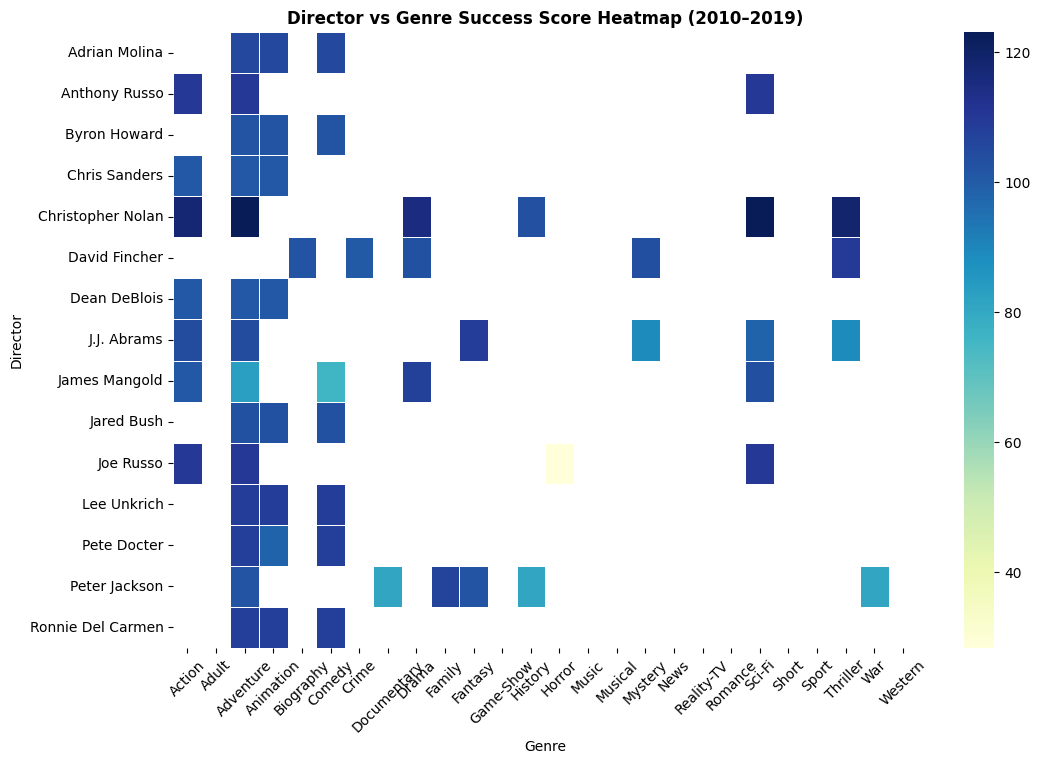

In [124]:
# Plotting a heatmap for this
plt.figure(figsize=(12, 8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Director vs Genre Success Score Heatmap (2010–2019)", fontweight='bold')
plt.xlabel("Genre")
plt.ylabel("Director")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()